势能-中枢分析系统启动...
数据形状: (100, 51)
数据日期范围: 2020-08-06 00:00:00 到 2020-12-31 00:00:00

2. 创建分析器...
检测到 3 个中枢区域:
  中枢1: 10.877 [10.789 - 10.891], 穿越K线: 8
  中枢2: 11.659 [11.573 - 11.769], 穿越K线: 34
  中枢3: 12.365 [12.211 - 12.433], 穿越K线: 22

3. 进行市场分析...
示例股票 当前市场分析报告

1. 价格位置分析:
   当前价格: 12.420
   相对于中枢1(10.877): 上方 12.31%
   相对于中枢2(11.659): 上方 5.24%
   相对于中枢3(12.365): 中枢内 94.3%

2. 势能状态:
   综合势能: 1.5124
   势能水平: 极高
   势能趋势: 加速上升
   交易信号: 强烈看跌

3. 势能成分:
   机械势能: -0.3424
   压力支撑: 1.9887
   趋势势能: 0.7596
   中枢势能: 2.1204
   突破势能: 2.6627

4. 操作建议:
   🔴 强烈卖出 - 高势能区域，回调风险大

4. 生成分析图表...


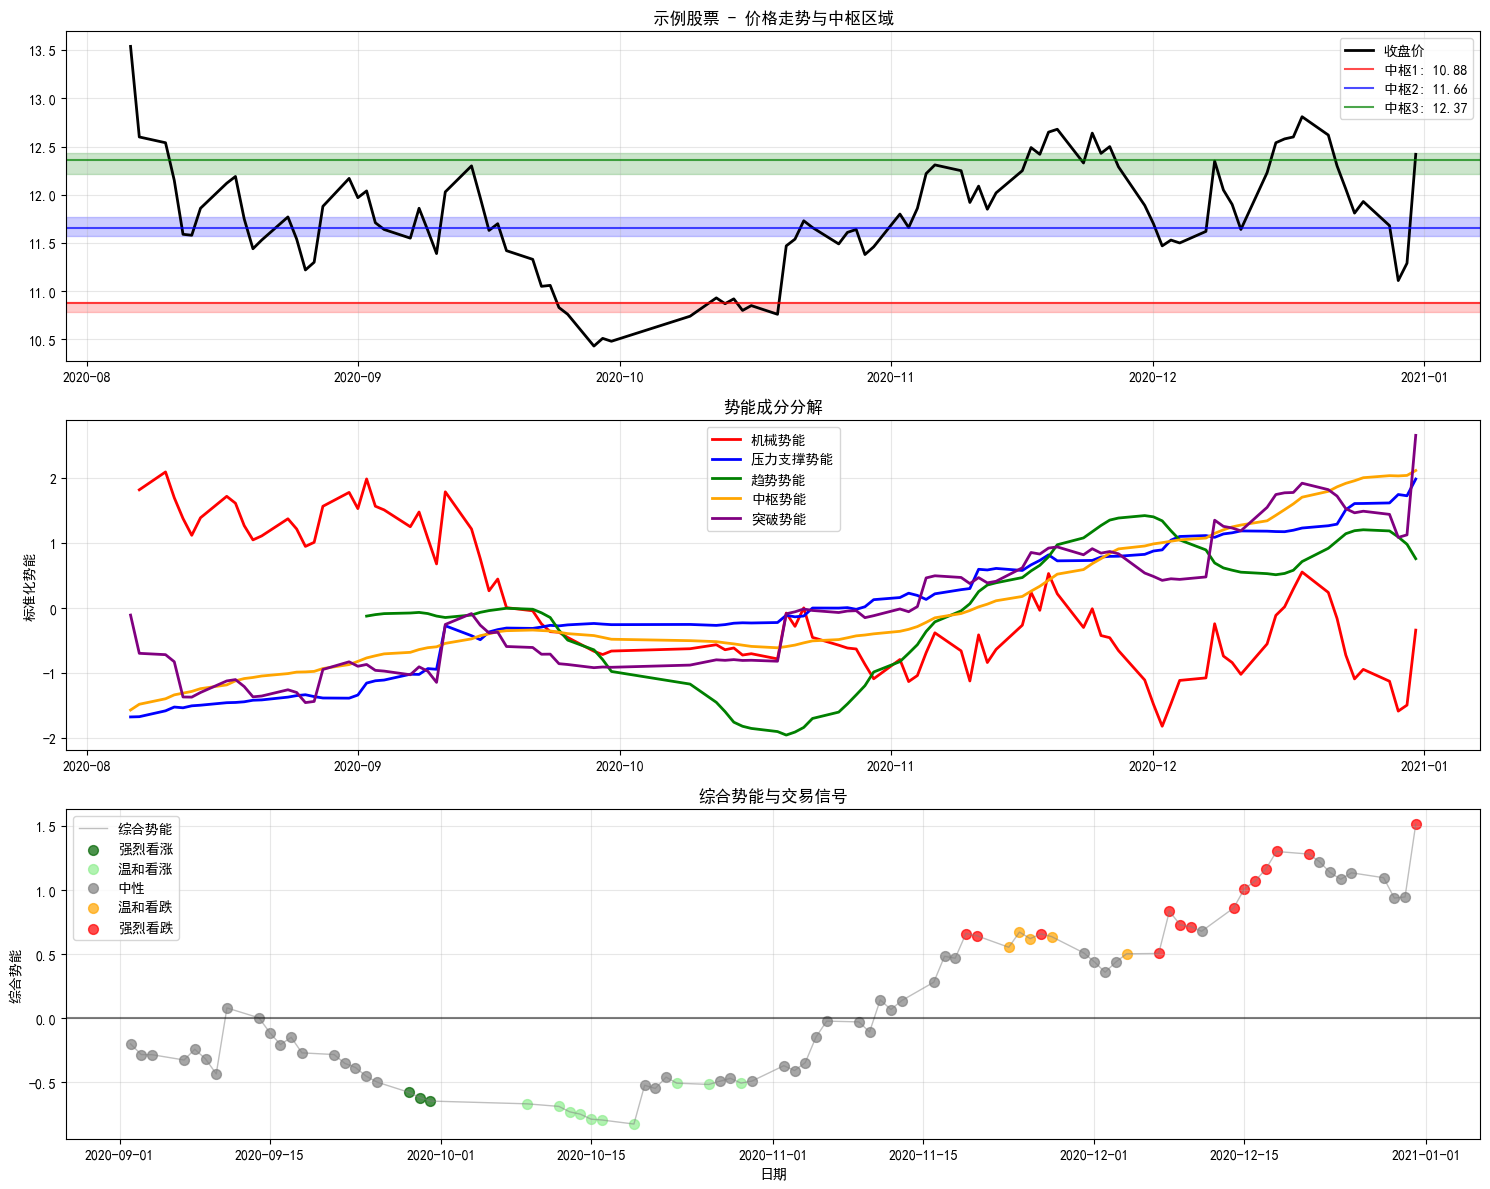

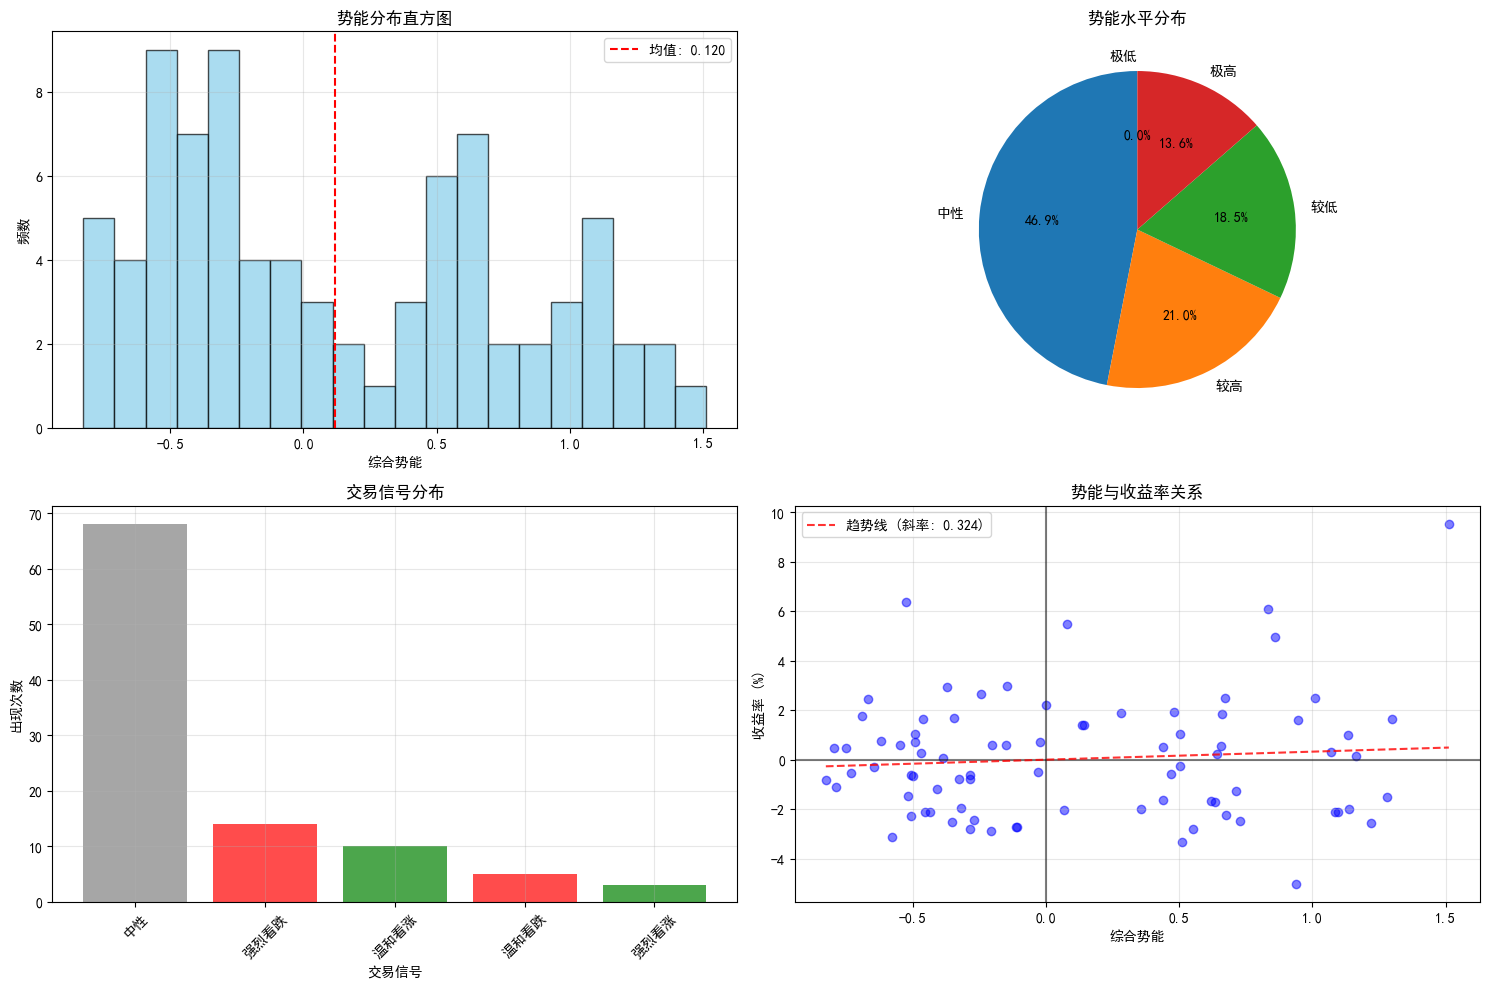


5. 保存分析结果...

分析完成！最终信号: 强烈看跌
结果数据已保存，包含 100 行记录

最后5个交易日的分析结果:
             open   high    low  close     volume  comprehensive_energy  \
trade_date                                                                
2020-12-25  11.74  12.02  11.69  11.93   49320.43              1.134108   
2020-12-28  11.88  11.95  11.61  11.68   46861.32              1.095933   
2020-12-29  11.69  12.05  11.08  11.11   72805.37              0.937054   
2020-12-30  11.02  11.45  11.01  11.29   50146.12              0.945925   
2020-12-31  11.60  12.42  11.30  12.42  164908.08              1.512423   

           energy_level energy_trend trading_signal  
trade_date                                           
2020-12-25           极高           平稳             中性  
2020-12-28           极高           平稳             中性  
2020-12-29           较高         加速下降             中性  
2020-12-30           较高         加速下降             中性  
2020-12-31           极高         加速上升           强烈看跌  


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False   # 用来正常显示负号

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=3):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域，确保不重叠"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离，防止重叠
        center_zones.sort(key=lambda x: x[0])
        
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            # 检查是否与已有区域重叠
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    # 有重叠，跳过这个区域
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        # 按中心线排序
        non_overlapping_zones.sort(key=lambda x: x[0])
        
        return non_overlapping_zones


class IntegratedEnergyCenterAnalyzer:
    def __init__(self, df, symbol="未知标的"):
        self.df = df.copy()
        self.symbol = symbol
        self.center_analyzer = KLineCenterAnalyzer()
        self.calculate_all_indicators()
    
    def calculate_all_indicators(self):
        """一次性计算所有指标"""
        # 1. 计算基础技术指标
        self.calculate_basic_indicators()
        
        # 2. 计算中枢
        self.calculate_centers()
        
        # 3. 计算各种势能
        self.calculate_energy_components()
        
        # 4. 生成信号
        self.generate_signals()
    
    def calculate_basic_indicators(self):
        """计算基础技术指标"""
        # 价格变化
        self.df['price_change'] = self.df['close'].pct_change()
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        
        # K线特征
        self.df['body_size'] = abs(self.df['close'] - self.df['open']) / self.df['open']
        self.df['total_range'] = (self.df['high'] - self.df['low']) / self.df['open']
        self.df['upper_shadow'] = (self.df['high'] - np.maximum(self.df['open'], self.df['close'])) / self.df['open']
        self.df['lower_shadow'] = (np.minimum(self.df['open'], self.df['close']) - self.df['low']) / self.df['open']
        self.df['price_position'] = (self.df['close'] - self.df['low']) / (self.df['high'] - self.df['low'])
        
        # 移动平均
        self.df['ma5'] = self.df['close'].rolling(5).mean()
        self.df['ma20'] = self.df['close'].rolling(20).mean()
        self.df['volume_ma5'] = self.df['volume'].rolling(5).mean()
    
    def calculate_centers(self):
        """计算中枢区域"""
        # 使用整个数据集计算中枢
        center_lines, reversal_points, volume_points = self.center_analyzer.find_centers(self.df)
        self.center_zones = self.center_analyzer.calculate_center_zones(self.df, center_lines)
        
        print(f"检测到 {len(self.center_zones)} 个中枢区域:")
        for i, (center, low, high, count) in enumerate(self.center_zones):
            print(f"  中枢{i+1}: {center:.3f} [{low:.3f} - {high:.3f}], 穿越K线: {count}")
    
    def calculate_center_energy(self):
        """计算基于中枢的势能 - 修正极性"""
        center_energy = []
        
        for i in range(len(self.df)):
            price = self.df['close'].iloc[i]
            total_energy = 0
            
            for center, zone_low, zone_high, strength in self.center_zones:
                # 计算强度权重
                zone_strength = np.log1p(strength)
                
                if price > zone_high:
                    # 在上方 - 正势能（上涨动力）- 修正极性
                    distance_ratio = (price - center) / (zone_high - center) if (zone_high - center) > 0 else 0
                    energy = distance_ratio * zone_strength  # 改为正数
                elif price < zone_low:
                    # 在下方 - 负势能（下跌压力）- 修正极性
                    distance_ratio = (center - price) / (center - zone_low) if (center - zone_low) > 0 else 0
                    energy = -distance_ratio * zone_strength  # 改为负数
                else:
                    # 在中枢内 - 根据位置决定
                    position = (price - zone_low) / (zone_high - zone_low) if (zone_high - zone_low) > 0 else 0.5
                    # 中枢上半部：轻微正势能；下半部：轻微负势能
                    energy = (position - 0.5) * 0.5 * zone_strength
                
                total_energy += energy
            
            center_energy.append(total_energy)
        
        return center_energy
    
    def calculate_breakout_energy(self):
        """计算突破势能"""
        breakout_energy = [0] * len(self.df)
        
        for i in range(1, len(self.df)):
            current = self.df.iloc[i]
            prev = self.df.iloc[i-1]
            
            # 突破前高
            if current['close'] > prev['high'] and current['volume'] > prev['volume']:
                breakout_energy[i] = current['log_return'] * current['volume'] * 2
            # 跌破前低
            elif current['close'] < prev['low'] and current['volume'] > prev['volume']:
                breakout_energy[i] = current['log_return'] * current['volume'] * 2
            # 普通情况
            else:
                breakout_energy[i] = current['log_return'] * current['volume']
        
        return breakout_energy
    
    def calculate_energy_components(self):
        """计算各种势能成分"""
        
        # 1. 基础动能势能
        self.df['kinetic_energy'] = self.df['log_return'] * self.df['volume']
        self.df['potential_energy'] = (self.df['price_position'] - 0.5) * self.df['volume'] * 2
        self.df['mechanical_energy'] = self.df['kinetic_energy'] + self.df['potential_energy']
        self.df['cumulative_mechanical'] = self.df['mechanical_energy'].cumsum()
        
        # 2. 压力支撑势能
        def pressure_support_energy(row):
            pressure = row['upper_shadow'] * row['volume']
            support = row['lower_shadow'] * row['volume']
            if row['close'] > row['open']:
                return support - pressure * 0.5
            else:
                return pressure - support * 0.5
        
        self.df['pressure_support_energy'] = self.df.apply(pressure_support_energy, axis=1)
        self.df['cumulative_pressure_support'] = self.df['pressure_support_energy'].cumsum()
        
        # 3. 趋势势能
        self.df['trend_strength'] = (self.df['ma5'] - self.df['ma20']) / self.df['ma20'] * 100
        self.df['trend_energy'] = self.df['trend_strength'] * self.df['volume'] / self.df['volume_ma5']
        self.df['cumulative_trend'] = self.df['trend_energy'].cumsum()
        
        # 4. 中枢势能（新增）
        self.df['center_energy'] = self.calculate_center_energy()
        self.df['cumulative_center'] = self.df['center_energy'].cumsum()
        
        # 5. 突破势能（保留）
        self.df['breakout_energy'] = self.calculate_breakout_energy()
        self.df['cumulative_breakout'] = self.df['breakout_energy'].cumsum()
        
        # 6. 综合势能（加权组合）
        # 标准化各成分
        energy_components = [
            'cumulative_mechanical', 
            'cumulative_pressure_support', 
            'cumulative_trend', 
            'cumulative_center',
            'cumulative_breakout'
        ]
        
        for col in energy_components:
            if self.df[col].std() > 0:
                self.df[f'normalized_{col}'] = (self.df[col] - self.df[col].mean()) / self.df[col].std()
            else:
                self.df[f'normalized_{col}'] = 0
        
        # 权重分配（中枢势能和突破势能占重要地位）
        weights = {
            'mechanical': 0.2,
            'pressure_support': 0.15, 
            'trend': 0.15,
            'center': 0.3,      # 中枢势能权重最大
            'breakout': 0.2     # 突破势能重要地位
        }
        
        self.df['comprehensive_energy'] = (
            weights['mechanical'] * self.df['normalized_cumulative_mechanical'] +
            weights['pressure_support'] * self.df['normalized_cumulative_pressure_support'] +
            weights['trend'] * self.df['normalized_cumulative_trend'] +
            weights['center'] * self.df['normalized_cumulative_center'] +
            weights['breakout'] * self.df['normalized_cumulative_breakout']
        )
        
        # 势能动量
        self.df['energy_momentum'] = self.df['comprehensive_energy'].diff(3)
    
    def generate_signals(self):
        """生成交易信号"""
        # 势能水平
        self.df['energy_level'] = pd.cut(
            self.df['comprehensive_energy'], 
            bins=[-np.inf, -1, -0.5, 0.5, 1, np.inf],
            labels=['极低', '较低', '中性', '较高', '极高']
        )
        
        # 势能趋势
        self.df['energy_trend'] = np.where(
            self.df['energy_momentum'] > 0.1, '加速上升',
            np.where(self.df['energy_momentum'] < -0.1, '加速下降', '平稳')
        )
        
        # 交易信号（修正逻辑：高势能看跌，低势能看涨）
        conditions = [
            (self.df['energy_level'].isin(['极高', '较高'])) & (self.df['energy_trend'] == '加速上升'),
            (self.df['energy_level'].isin(['极低', '较低'])) & (self.df['energy_trend'] == '加速下降'),
            (self.df['energy_level'].isin(['较高'])) & (self.df['energy_trend'] == '平稳'),
            (self.df['energy_level'].isin(['较低'])) & (self.df['energy_trend'] == '平稳')
        ]
        choices = ['强烈看跌', '强烈看涨', '温和看跌', '温和看涨']
        self.df['trading_signal'] = np.select(conditions, choices, default='中性')
    
    def analyze_current_situation(self):
        """分析当前市场状况"""
        if len(self.df) == 0:
            return "无数据"
        
        current = self.df.iloc[-1]
        current_price = current['close']
        
        print("="*60)
        print(f"{self.symbol} 当前市场分析报告")
        print("="*60)
        
        print(f"\n1. 价格位置分析:")
        print(f"   当前价格: {current_price:.3f}")
        
        # 分析价格相对于中枢的位置
        for i, (center, low, high, strength) in enumerate(self.center_zones):
            position = ""
            if current_price > high:
                position = f"上方 {(current_price-high)/current_price*100:.2f}%"
            elif current_price < low:
                position = f"下方 {(low-current_price)/current_price*100:.2f}%"
            else:
                position = f"中枢内 {((current_price-low)/(high-low)*100):.1f}%"
            
            print(f"   相对于中枢{i+1}({center:.3f}): {position}")
        
        print(f"\n2. 势能状态:")
        print(f"   综合势能: {current['comprehensive_energy']:.4f}")
        print(f"   势能水平: {current['energy_level']}")
        print(f"   势能趋势: {current['energy_trend']}")
        print(f"   交易信号: {current['trading_signal']}")
        
        print(f"\n3. 势能成分:")
        print(f"   机械势能: {current['normalized_cumulative_mechanical']:.4f}")
        print(f"   压力支撑: {current['normalized_cumulative_pressure_support']:.4f}")
        print(f"   趋势势能: {current['normalized_cumulative_trend']:.4f}")
        print(f"   中枢势能: {current['normalized_cumulative_center']:.4f}")
        print(f"   突破势能: {current['normalized_cumulative_breakout']:.4f}")
        
        print(f"\n4. 操作建议:")
        signal = current['trading_signal']
        if '强烈看涨' in signal:
            print("   🟢 强烈买入 - 低势能区域，反弹概率高")
        elif '温和看涨' in signal:
            print("   🟡 考虑买入 - 较低势能，有上涨潜力") 
        elif '强烈看跌' in signal:
            print("   🔴 强烈卖出 - 高势能区域，回调风险大")
        elif '温和看跌' in signal:
            print("   🟠 考虑减仓 - 较高势能，注意风险")
        else:
            print("   ⚪ 保持观望 - 势能中性，等待明确信号")
        
        return current['trading_signal']
    
    def plot_comprehensive_analysis(self):
        """绘制综合分析图表"""
        fig, axes = plt.subplots(3, 1, figsize=(15, 12))
        
        # 图1: 价格走势与中枢
        ax1 = axes[0]
        ax1.plot(self.df.index, self.df['close'], label='收盘价', color='black', linewidth=2)
        
        # 绘制中枢区域
        colors = ['red', 'blue', 'green']
        for idx, (center, low, high, count) in enumerate(self.center_zones):
            if idx < len(colors):
                ax1.axhline(y=center, color=colors[idx], linestyle='-', alpha=0.7, 
                           label=f'中枢{idx+1}: {center:.2f}')
                ax1.axhspan(low, high, alpha=0.2, color=colors[idx])
        
        ax1.set_title(f'{self.symbol} - 价格走势与中枢区域')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 图2: 势能成分分解
        ax2 = axes[1]
        ax2.plot(self.df.index, self.df['normalized_cumulative_mechanical'], 
                label='机械势能', color='red', linewidth=2)
        ax2.plot(self.df.index, self.df['normalized_cumulative_pressure_support'], 
                label='压力支撑势能', color='blue', linewidth=2)
        ax2.plot(self.df.index, self.df['normalized_cumulative_trend'], 
                label='趋势势能', color='green', linewidth=2)
        ax2.plot(self.df.index, self.df['normalized_cumulative_center'], 
                label='中枢势能', color='orange', linewidth=2)
        ax2.plot(self.df.index, self.df['normalized_cumulative_breakout'], 
                label='突破势能', color='purple', linewidth=2)
        ax2.set_ylabel('标准化势能')
        ax2.set_title('势能成分分解')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 图3: 综合势能与交易信号
        ax3 = axes[2]
        ax3.plot(self.df.index, self.df['comprehensive_energy'], 
                color='gray', alpha=0.5, linewidth=1, label='综合势能')
        
        # 根据信号着色
        signal_colors = {
            '强烈看涨': 'darkgreen',
            '温和看涨': 'lightgreen',
            '中性': 'gray',
            '温和看跌': 'orange',
            '强烈看跌': 'red'
        }
        
        for signal in signal_colors.keys():
            mask = self.df['trading_signal'] == signal
            if mask.any():
                ax3.scatter(self.df.index[mask], self.df['comprehensive_energy'][mask],
                          color=signal_colors[signal], label=signal, s=50, alpha=0.7)
        
        ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax3.set_ylabel('综合势能')
        ax3.set_xlabel('日期')
        ax3.set_title('综合势能与交易信号')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_energy_statistics(self):
        """绘制势能统计图表"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 势能分布直方图
        valid_energy = self.df['comprehensive_energy'].dropna()
        axes[0,0].hist(valid_energy, bins=20, 
                      color='skyblue', edgecolor='black', alpha=0.7)
        axes[0,0].axvline(valid_energy.mean(), 
                         color='red', linestyle='--', label=f'均值: {valid_energy.mean():.3f}')
        axes[0,0].set_xlabel('综合势能')
        axes[0,0].set_ylabel('频数')
        axes[0,0].set_title('势能分布直方图')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # 势能水平分布
        energy_level_counts = self.df['energy_level'].value_counts()
        axes[0,1].pie(energy_level_counts.values, labels=energy_level_counts.index, 
                     autopct='%1.1f%%', startangle=90)
        axes[0,1].set_title('势能水平分布')
        
        # 交易信号分布
        signal_counts = self.df['trading_signal'].value_counts()
        colors = ['green' if '涨' in x else 'red' if '跌' in x else 'gray' 
                 for x in signal_counts.index]
        axes[1,0].bar(signal_counts.index, signal_counts.values, color=colors, alpha=0.7)
        axes[1,0].set_xlabel('交易信号')
        axes[1,0].set_ylabel('出现次数')
        axes[1,0].set_title('交易信号分布')
        axes[1,0].tick_params(axis='x', rotation=45)
        axes[1,0].grid(True, alpha=0.3)
        
        # 势能与收益率关系
        temp_df = self.df[['comprehensive_energy', 'log_return']].dropna()
        if len(temp_df) > 0:
            axes[1,1].scatter(temp_df['comprehensive_energy'], temp_df['log_return']*100,
                             alpha=0.5, color='blue')
            axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
            axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.5)
            axes[1,1].set_xlabel('综合势能')
            axes[1,1].set_ylabel('收益率 (%)')
            axes[1,1].set_title('势能与收益率关系')
            axes[1,1].grid(True, alpha=0.3)
            
            # 添加趋势线
            if len(temp_df) > 1:
                z = np.polyfit(temp_df['comprehensive_energy'], temp_df['log_return']*100, 1)
                p = np.poly1d(z)
                x_range = np.linspace(temp_df['comprehensive_energy'].min(), 
                                     temp_df['comprehensive_energy'].max(), 100)
                axes[1,1].plot(x_range, p(x_range), "r--", alpha=0.8, 
                              label=f'趋势线 (斜率: {z[0]:.3f})')
                axes[1,1].legend()
        else:
            axes[1,1].text(0.5, 0.5, '无有效数据', ha='center', va='center', 
                          transform=axes[1,1].transAxes)
            axes[1,1].set_title('势能与收益率关系 (无数据)')
        
        plt.tight_layout()
        plt.show()


# 使用示例和测试数据生成
def generate_sample_data(days=100, start_price=100):
    """生成示例数据用于测试"""
    np.random.seed(42)
    
    dates = pd.date_range(start='2023-01-01', periods=days, freq='D')
    
    # 生成价格数据（带趋势和波动）
    returns = np.random.normal(0.001, 0.02, days)
    prices = start_price * np.cumprod(1 + returns)
    
    # 生成OHLC数据
    data = []
    for i in range(days):
        open_price = prices[i] * (1 + np.random.normal(0, 0.005))
        close_price = prices[i] * (1 + np.random.normal(0, 0.005))
        high = max(open_price, close_price) * (1 + abs(np.random.normal(0, 0.01)))
        low = min(open_price, close_price) * (1 - abs(np.random.normal(0, 0.01)))
        volume = np.random.randint(100000, 1000000)
        
        data.append({
            'date': dates[i],
            'open': open_price,
            'high': high,
            'low': low,
            'close': close_price,
            'volume': volume
        })
    
    df = pd.DataFrame(data)
    df.set_index('date', inplace=True)
    return df


# 主函数
def main():
    """主函数 - 演示完整分析流程"""
    print("势能-中枢分析系统启动...")
    
    # 生成示例数据或使用真实数据
    # 数据加载
    ts_code = "603979.SH"
    csv_path = fr'E:\stock\csv_version\analysis_results\{ts_code}_analysis.csv'    
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
    print(f"数据形状: {df.shape}")
    print(f"数据日期范围: {df.index[0]} 到 {df.index[-1]}")
    
    # 创建分析器
    print("\n2. 创建分析器...")
    analyzer = IntegratedEnergyCenterAnalyzer(df, symbol="示例股票")
    
    # 分析当前状况
    print("\n3. 进行市场分析...")
    current_signal = analyzer.analyze_current_situation()
    
    # 绘制图表
    print("\n4. 生成分析图表...")
    analyzer.plot_comprehensive_analysis()
    analyzer.plot_energy_statistics()
    
    # 保存结果
    print("\n5. 保存分析结果...")
    output_columns = ['open', 'high', 'low', 'close', 'volume', 
                     'comprehensive_energy', 'energy_level', 'energy_trend', 'trading_signal']
    result_df = analyzer.df[output_columns].copy()
    
    print(f"\n分析完成！最终信号: {current_signal}")
    print(f"结果数据已保存，包含 {len(result_df)} 行记录")
    
    return analyzer, result_df


if __name__ == "__main__":
    # 运行完整分析
    analyzer, results = main()
    
    # 显示最后几行结果
    print("\n最后5个交易日的分析结果:")
    print(results.tail())